In [1]:
from datetime import datetime
import numpy as np
from cpuinfo import get_cpu_info
from Analysis.visualization import VisualTool
from Engine.map_loader import MapLoader
from Engine.masks import layer_map

In [2]:
vis=VisualTool(show=True, size=(10,10), save=True, dpi=100, save_dir="__RESULTS__/_plots")

### Overview of Construction site map

In [3]:
map=MapLoader().load("gangjin/full")

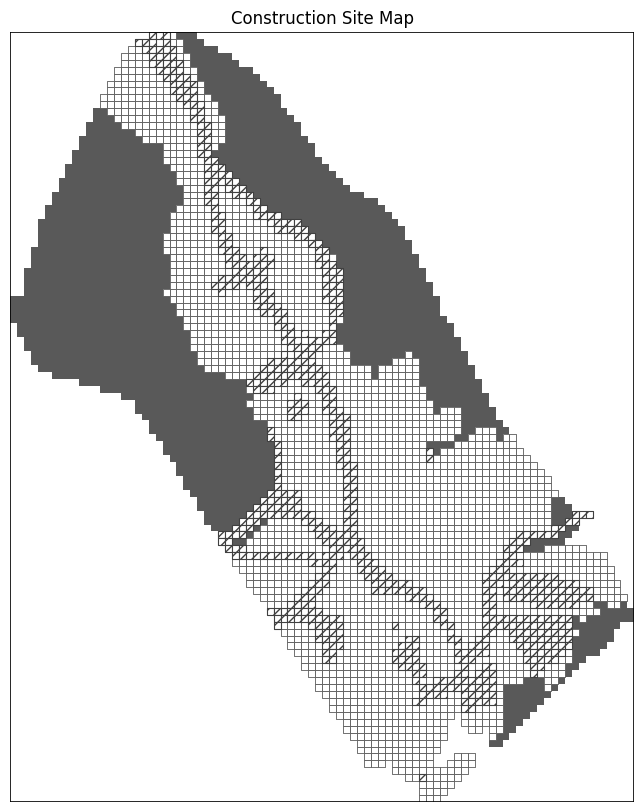

Saved figure: __RESULTS__/_plots/06-09-04-19/construction_map.png


In [4]:
vis.showMap(map_data=map, title="Construction Site Map", cmap='gray', filename="construction_map")

Installable map
<br><sub> A binary grid mask that defines physically feasible sensor deployment locations on the site. </sub>

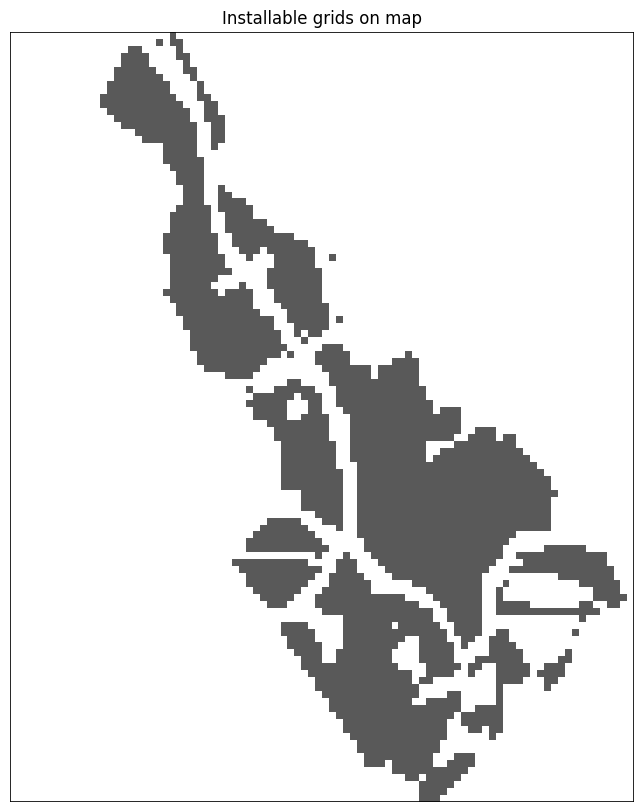

Saved figure: __RESULTS__/_plots/06-09-04-19/installable_map.png


In [5]:
installable_layer = layer_map(map, keep_values=[2])
vis.showMap(map_data=installable_layer, title="Installable grids on map", cmap='jet', filename="installable_map")

Uninstallable map
<br><sub>Regions excluded from sensor deployment due to safety, accessibility, or operational constraints <br>(e.g., equipment routes, waterlogged areas, vegetation, and offices).</sub>

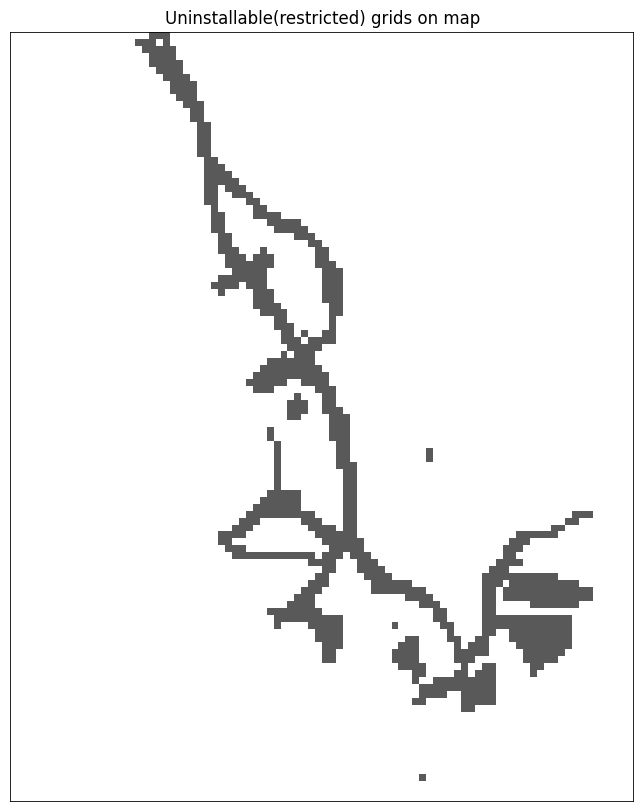

Saved figure: __RESULTS__/_plots/06-09-04-19/restricted__map.png


In [6]:
road_layer = layer_map(map, keep_values=[3])
vis.showMap(map_data=road_layer, title="Uninstallable(restricted) grids on map", cmap="gray", filename="restricted__map")

Jobsite area
<br><sub>The coverage target area for sensor deployment, defined as the union of installable and non-installable regions.</sub>

========== MAP CHECK ==========
Map shape (H,W): 111 x 90
Grid size: 5.0m x 5.0m  |  Cell area: 25.0 m^2
--------------------------------
Total cells: 9,990
Total area : 249,750.00 m^2  |  24.9750 ha  |  0.249750 km^2
--------------------------------
Target value      : 1
Target area       : 72,550.00 m^2  |  7.2550 ha  |  0.072550 km^2
Target cells      : 2,902  (29.05%)
--------------------------------
Value counts (entire map):
  - value 0: 7,088 (70.95%)
  - value 1: 2,902 (29.05%)


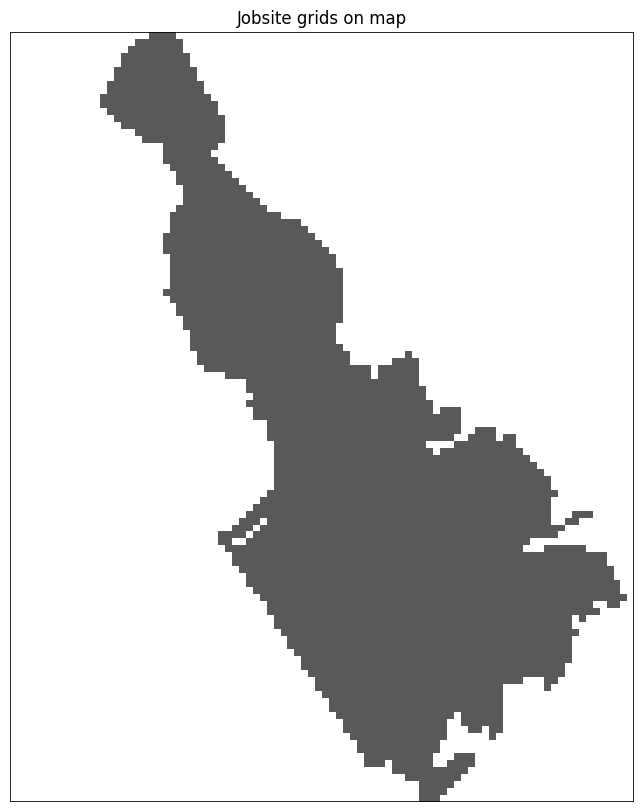

Saved figure: __RESULTS__/_plots/06-09-04-19/map_check.png


In [7]:
jobsite_layer = layer_map(map, keep_values=[2,3])
vis.map_check(map_data=jobsite_layer,title="Jobsite grids on map", return_stats=False, cmap="gray")

### Systematic sensor deployment

In [8]:
#Set sensor coverage radius
COVERAGE = 45

Outermost corner location candidate extraction
<br><sub> Detection of outermost feasible sensor placement candidates within installable regions, since environmental sensing modules must be deployed at the site boundaries to capture extreme conditions. </sub>

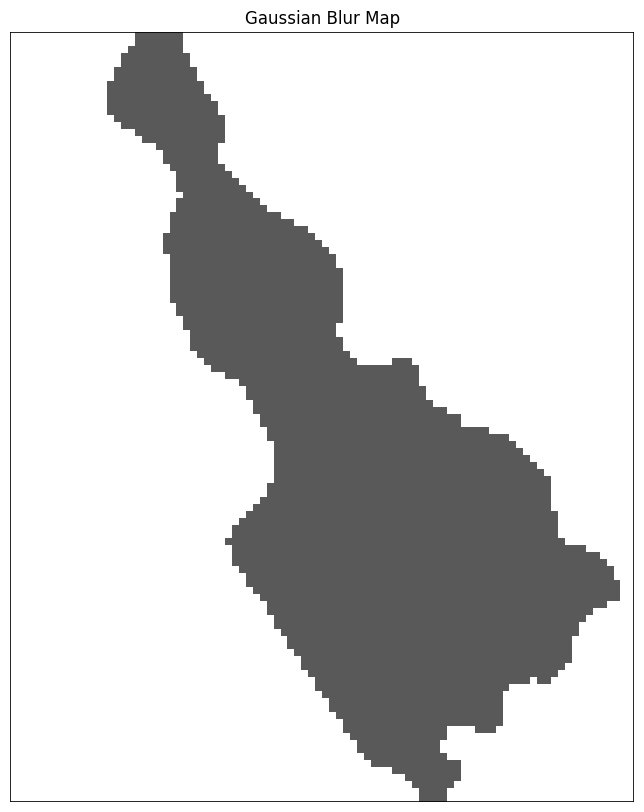

Saved figure: __RESULTS__/_plots/06-09-04-19/gaussian_blur_map.png


In [9]:
from OuterDeployment.HarrisCorner import HarrisCorner

corner_instance = HarrisCorner(jobsite_layer)

blur_map = corner_instance.gaussianBlur(grid=jobsite_layer)
vis.showMap(map_data=blur_map, title="Gaussian Blur Map", cmap='gray', filename="gaussian_blur_map")

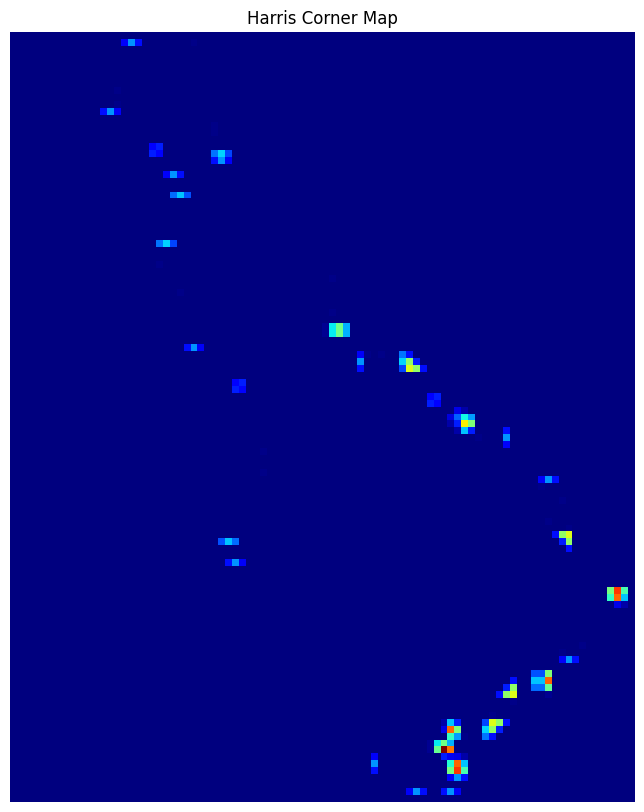

Saved figure: __RESULTS__/_plots/06-09-04-19/harris_corner_map.png


In [10]:
corner_heatmap = corner_instance.harrisCorner(
                                                grid=blur_map,
                                                block_size=3,
                                                ksize=3,
                                                k=0.05
                                                )
vis.showMap(map_data=corner_heatmap, title="Harris Corner Map", cmap="jet", filename="harris_corner_map")

Total outermost sensors : 8


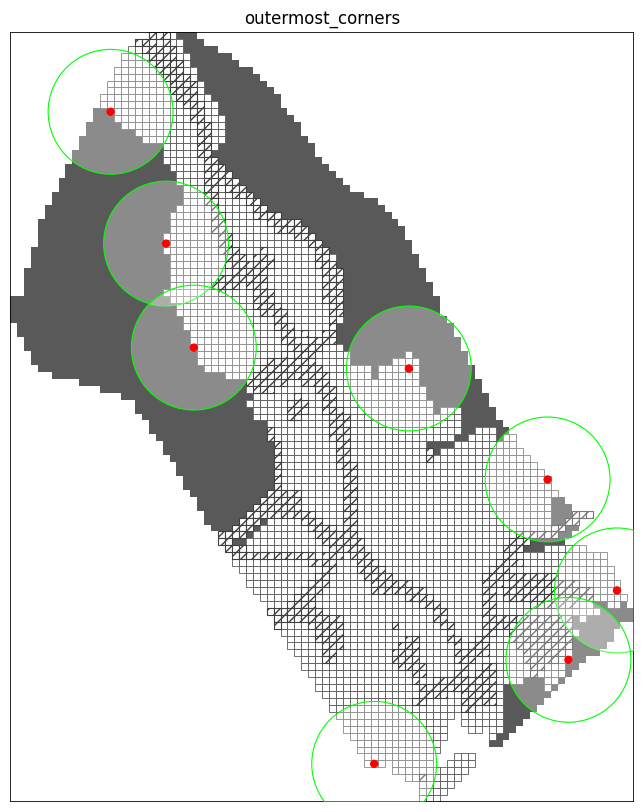

Saved figure: __RESULTS__/_plots/06-09-04-19/corner_sensors.png


In [11]:
corners = corner_instance.LMX(harris_map=corner_heatmap, installable_map=installable_layer, min_dist=9)

print("Total outermost sensors :",len(corners))
vis.showMap_circle(
    map_data=map, 
    sensor_positions=corners, 
    title="outermost_corners",
    cmap="gray",
    filename="corner_sensors"
    )

Outmost corner points: 8


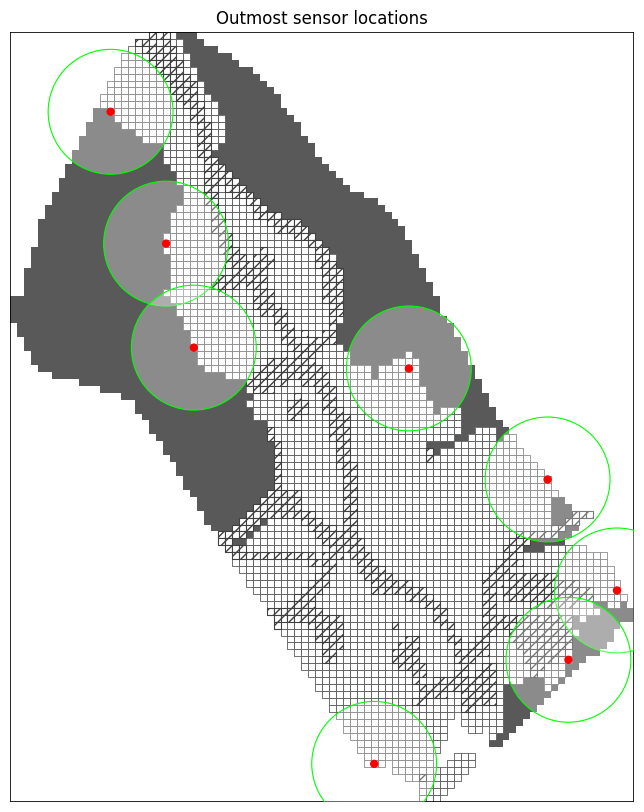

Saved figure: __RESULTS__/_plots/06-09-04-19/corner_sensors.png


In [12]:
corner_layer = HarrisCorner(jobsite_layer)
corner_candidate = corner_layer.run(
    grid=jobsite_layer,                
    installable_layer=installable_layer, 
    blockSize=3,
    ksize=3,
    k=0.05,
    dilate_size=5,
    min_dist=9,
)

print("Outmost corner points:", len(corner_candidate))
vis.showMap_circle(map_data=map, sensor_positions=corner_candidate, title="Outmost sensor locations",radius=COVERAGE, cmap='gray', filename="corner_sensors")

Inner-Deployment Strategy: Greedy Search
<br><sub>Greedy search is used to place inner sensors by repeatedly selecting the installable location with the largest marginal coverage gain while preserving the same preprocessing flow.</sub>

In [13]:
from InnerDeployment.Greedy.main import SensorGreedy

greedy = SensorGreedy(
                installable_map=installable_layer,
                jobsite_map=jobsite_layer,
                coverage=COVERAGE,
                corner_positions=corner_candidate,
                min_sensors=0,
                max_sensors=140,
                candidate_stride=1,
                fitness_kwargs={"target_coverage": 100.0},
            )

optimized_result = greedy.run(
                    target_coverage=100.0,
                    max_sensors=140,
                    return_best_only=True
                )

[Greedy 000] sensors=0 / coverage=27.43% (target=100.00%)
[Greedy 001] sensors=1 / coverage=36.15% (target=100.00%)
[Greedy 002] sensors=2 / coverage=44.87% (target=100.00%)
[Greedy 003] sensors=3 / coverage=53.45% (target=100.00%)
[Greedy 004] sensors=4 / coverage=61.51% (target=100.00%)
[Greedy 005] sensors=5 / coverage=69.06% (target=100.00%)
[Greedy 006] sensors=6 / coverage=75.12% (target=100.00%)
[Greedy 007] sensors=7 / coverage=80.88% (target=100.00%)
[Greedy 008] sensors=8 / coverage=85.01% (target=100.00%)
[Greedy 009] sensors=9 / coverage=89.11% (target=100.00%)
[Greedy 010] sensors=10 / coverage=92.90% (target=100.00%)
[Greedy 011] sensors=11 / coverage=94.49% (target=100.00%)
[Greedy 012] sensors=12 / coverage=95.76% (target=100.00%)
[Greedy 013] sensors=13 / coverage=97.21% (target=100.00%)
[Greedy 014] sensors=14 / coverage=98.55% (target=100.00%)
[Greedy 015] sensors=15 / coverage=99.07% (target=100.00%)
[Greedy 016] sensors=16 / coverage=99.14% (target=100.00%)
[Greedy

In [14]:
print("[FINALIZE OUTPUT] greedy.best_solution =", greedy.best_solution)
print("[FINALIZE OUTPUT] len(greedy.best_solution) =", len(greedy.best_solution))
print("[FINALIZE OUTPUT] greedy.corner_points =", greedy.corner_points)
print("[FINALIZE OUTPUT] len(greedy.corner_points) =", len(greedy.corner_points))

[FINALIZE OUTPUT] greedy.best_solution = [(47, 63), (61, 74), (49, 87), (39, 36), (64, 91), (38, 76), (42, 51), (29, 15), (62, 63), (72, 77), (23, 0), (64, 106), (32, 30), (50, 72), (49, 96), (64, 54), (39, 85), (47, 41), (70, 98), (58, 83), (54, 57), (58, 98)]
[FINALIZE OUTPUT] len(greedy.best_solution) = 22
[FINALIZE OUTPUT] greedy.corner_points = [(14, 11), (22, 30), (26, 45), (57, 48), (77, 64), (87, 80), (80, 90), (52, 105)]
[FINALIZE OUTPUT] len(greedy.corner_points) = 8


Total number of Sensor : 30


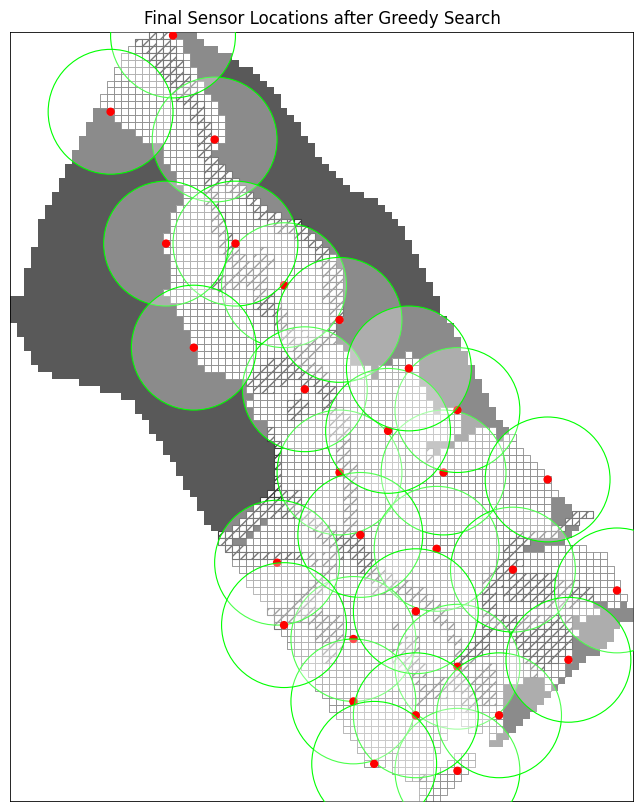

Saved figure: __RESULTS__/_plots/06-09-04-19/final_sensors_greedy.png


In [15]:
final_result = optimized_result + corner_candidate
print("Total number of Sensor :", len(final_result))
vis.showMap_circle(
    map_data=map, 
    sensor_positions=final_result,
    title="Final Sensor Locations after Greedy Search",
    radius=COVERAGE,
    cmap='gray',
    filename="final_sensors_greedy"
    )